<img src = "images/example1_2.PNG" width = "300">

<img src = "images/example1_1.PNG" width = "500">

In [1]:
import numpy as np
import weld_calc as wc

In [2]:
# definir algunas variables del problema
b1 = 30. / 1000
b2 = 50. / 1000
c = 150. / 1000
d = 50. / 1000
h = 5. / 1000

# crear el primer cordón
c1 = wc.Weld()   # c1 es un objeto de la clase Weld
c1.h = h         # es el tamaño del cordón
# los cordones siempre deben estar en las dos primeras coordenadas
c1.start_point = np.array([0., 0., 0.])
c1.end_point = np.array([b2, 0., 0.])
c1.weld_calcs()   # se calcula internamente variables del cordón
                  # es un método de la clase Weld()
c1.print_report() # método de la clase Weld() muestra un reporte de variables internas
c1.color = "black"
c1.name = "c1"

############
--- REPORT ---
############
Name  = Weld 1
l     = 0.050000 m
Area  = 0.000177 m²
JG    = 0.000000 m⁴
Ixx_loc = 0.000000 m⁴
Iyy_loc = 0.000000 m⁴
Ixy_loc = 0.000000 m⁴
Centroid:
xG    = 0.025000 m
yG    = 0.000000 m
Angle = 0.00°


In [3]:
c2 = wc.Weld()
c2.h = h
c2.start_point = np.array([0., 0., 0.])
c2.end_point = np.array([0., d, 0.])
c2.weld_calcs()
c2.color = "green"
c2.name = "c2"
c2.print_report()

############
--- REPORT ---
############
Name  = c2
l     = 0.050000 m
Area  = 0.000177 m²
JG    = 0.000000 m⁴
Ixx_loc = 0.000000 m⁴
Iyy_loc = 0.000000 m⁴
Ixy_loc = 0.000000 m⁴
Centroid:
xG    = 0.000000 m
yG    = 0.025000 m
Angle = 90.00°


In [4]:
c3 = wc.Weld()
c3.h = h
c3.start_point = np.array([0., d, 0.])
c3.end_point = np.array([b1, d, 0.])
c3.weld_calcs()
c3.color = "blue"
c3.name = "c3"

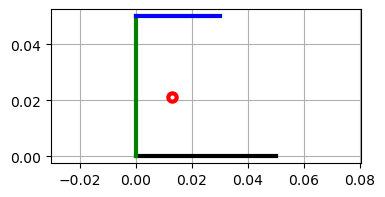

In [5]:
wj = wc.Weld_joint()   # se crea un objeto llamado wj de la clase Weld_joint()
wj.welds = [c1, c2, c3]    # se guardan en una lista los cordones definidos  
wj.weld_calcs()        # cálculos internos de la unión soldada
wj.figure_size = (4, 2)     # tupla con tamaño de imagen (pulgadas)
wj.plot_welds()

In [6]:
F = np.array([0., -1000., 0.])       # vector que almacena la fuerza
point = np.array([b2 + c, d, 0.])    # Punto donde está aplicada la fuerza
position = np.array([b2, 0., 0.])    # Posición donde quiero calcular
forces = [F]
points = [point]
wj.weld_point_evaluation(forces, points, position)      # método que evalua la tensión

In [7]:
wj.tau_1 / 1e6

array([-0.        ,  2.17571317, -0.        ])

In [8]:
wj.tau_2 / 1e6

array([12.84559223, 22.42139734,  0.        ])

In [9]:
n_points = 12
eq1 = wc.equidistant_points(c1, n_points)
eq2 = wc.equidistant_points(c2, n_points)
eq3 = wc.equidistant_points(c3, n_points)

weld_points = np.vstack((eq1, eq2, eq3))
weld_points = wc.remove_repeats(weld_points)

In [10]:
wj.weld_evaluation(forces, points, weld_points)

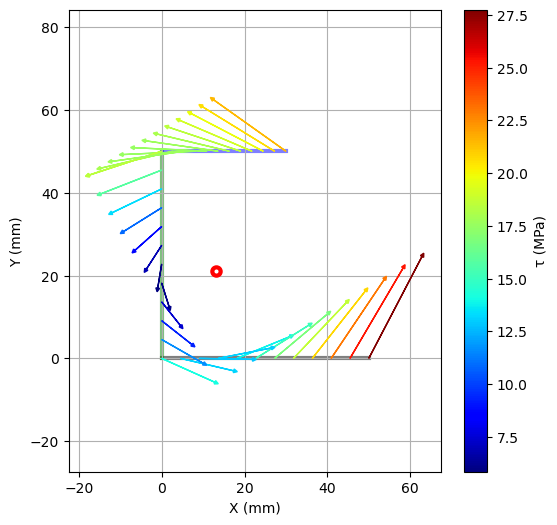

In [11]:
wj.figure_size = (6, 6)    # tamaño de figura (9 x 6) pulgadas
# Si se desea ver también las componentes por separado, se puede llamar de nuevo:
wj.plot_vectors(
    weld_points,
    plot_type='tau',
    scale_vectors=0.3,
    scale_magnitud=1e-6,
    scale_points=1000,
    plot_TAU_1=False,           # muestra TAU_1 con línea discontinua gris
    plot_TAU_2=False,           # muestra TAU_2 con línea punteada gris
    show_weld_lines=True
)

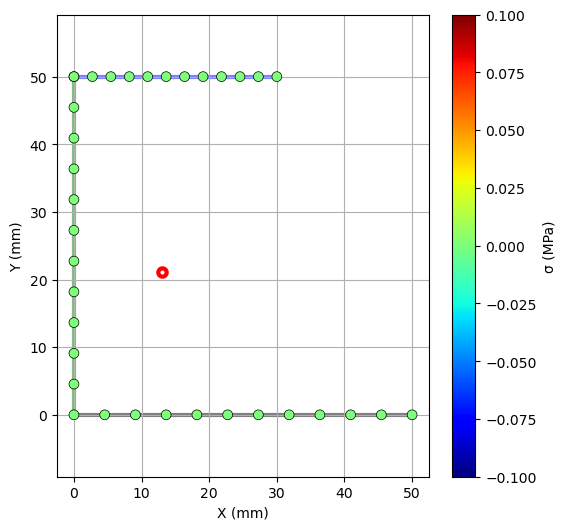

In [12]:
# Tensiones normales
wj.plot_vectors(weld_points, plot_type = 'sigma', save_figure=True)
wj.figure_name = "tensiones_normales.png"

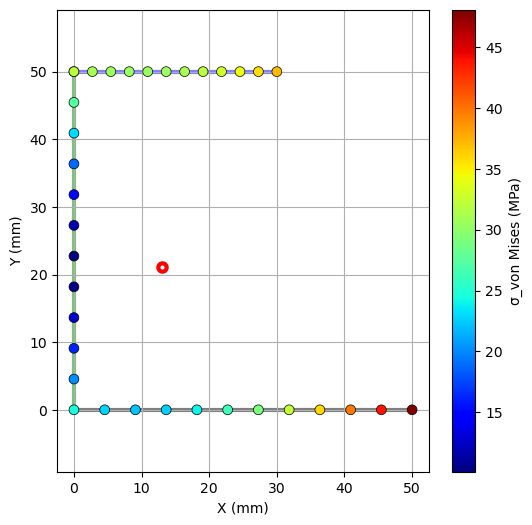

In [13]:
# Tensión de von Mises
wj.plot_vectors(weld_points, plot_type = 'von_mises', save_figure=True)
wj.figure_name = "von_mises.png"

In [14]:
# 1. Factor de seguridad
fluencia = 250e6  # 250 MPa
n_min, n_list = wj.safety_factor(yield_strength = fluencia, criterion = 'vm')
print(f"Factor de seguridad mínimo (von Mises): {n_min:.2f}")

Factor de seguridad mínimo (von Mises): 5.20


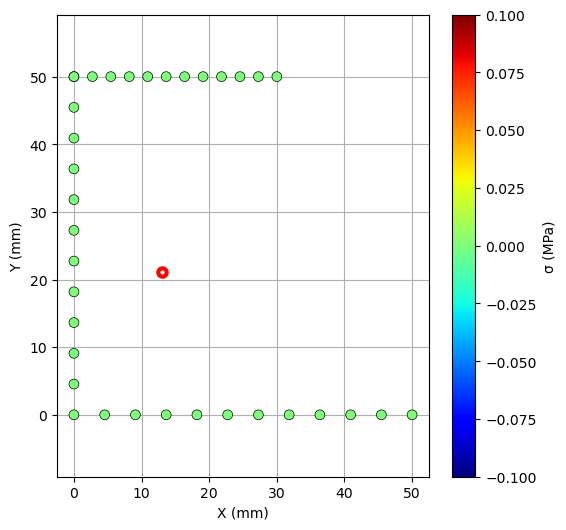

In [15]:
# 3. Plot de vectores sin líneas de cordones (solo puntos)
wj.plot_vectors(weld_points, plot_type='sigma', show_weld_lines=False)

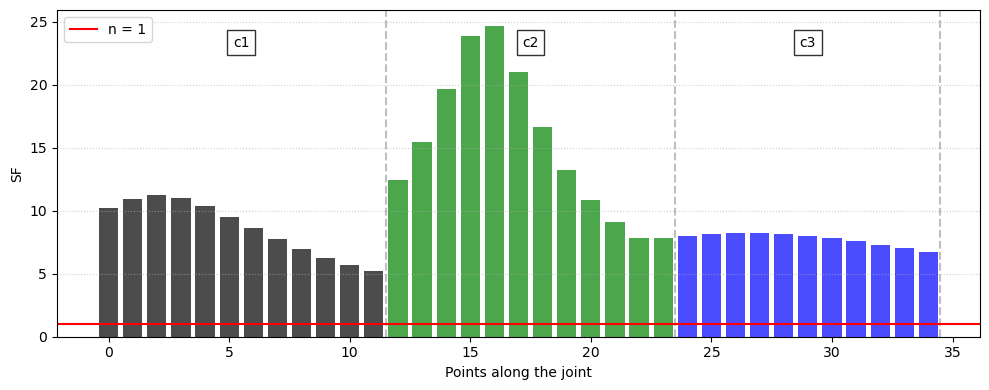

In [16]:
wj.plot_n_unfolded(weld_points, fluencia, criterion = 'vm')